# 1. Импорт библиотек и функций

## 1.1. Библиотеки

In [1]:
import re
import string
import nltk
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

## 1.2. Функции

In [2]:
def plot_topic_barchart(df, topic_col = 'topic', figsize = (12, 6)):
    """
    Столбчатая диаграмма распределения тематических категорий
    """
    # Подсчет частот тем
    topic_counts = df[topic_col].value_counts().sort_values(ascending=False)
    
    # Создание графика
    plt.figure(figsize=figsize)
    bars = plt.bar(range(len(topic_counts)), topic_counts.values, 
                   color=plt.cm.Set3(np.linspace(0, 1, len(topic_counts))))
    
    plt.title('Распределение новостей по темам', fontsize=14, fontweight='bold')
    plt.ylabel('Количество новостей', fontsize=12)
    plt.xlabel('Темы', fontsize=12)
    plt.xticks(range(len(topic_counts)), topic_counts.index, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Добавляем значения на столбцы
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01 * max(topic_counts.values),
                f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

In [3]:
def plot_topic_timeseries(df, topic_col = 'topic', date_col = 'date', top_n = 4, figsize = (14, 6)):
    """
    Временной ряд публикаций по топ-N темам
    """
    # Преобразуем дату если нужно
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df[date_col]):
        df[date_col] = pd.to_datetime(df[date_col])
    
    # Получаем топ темы
    top_topics = df[topic_col].value_counts().head(top_n).index
    
    # Группируем по дате и теме
    topic_time_series = df[df[topic_col].isin(top_topics)].groupby(
        [df[date_col].dt.to_period('M'), topic_col]
    ).size().unstack().fillna(0)
    
    # Построение графика
    plt.figure(figsize=figsize)
    topic_time_series.plot(kind='line', marker='o', ax=plt.gca())
    plt.title(f'Динамика публикаций по темам', fontsize=14, fontweight='bold')
    plt.ylabel('Количество новостей в месяц')
    plt.xlabel('Дата')
    plt.legend(title='Темы', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [48]:
def plot_word_count_distribution(df, text_col = 'text', figsize = (10, 6)):
    """
    Распределение длины текста (слова)
    """
    df = df.copy()
    df['word_count'] = df[text_col].str.split().str.len()
    
    plt.figure(figsize=figsize)
    plt.hist(df['word_count'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(df['word_count'].mean(), color='red', linestyle='--', 
                label=f'Среднее: {df["word_count"].mean():.1f} слов')
    plt.title('Распределение длины текстов', fontweight='bold')
    plt.xlabel('Количество слов')
    plt.ylabel('Частота')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [5]:
def plot_daily_word_length_evolution(df, text_col = 'text', date_col = 'date', figsize = (12, 6)):
    """
    Динамика средней длины новостей (слова) по дням
    """
    df = df.copy()
    df['word_count'] = df[text_col].str.split().str.len()
    
    if not pd.api.types.is_datetime64_any_dtype(df[date_col]):
        df[date_col] = pd.to_datetime(df[date_col])
    
    daily_avg = df.groupby(df[date_col].dt.date)['word_count'].mean()
    
    plt.figure(figsize=figsize)
    plt.plot(daily_avg.index, daily_avg.values, linewidth=1)
    plt.title('Динамика средней длины новостей по дням', fontweight='bold')
    plt.xlabel('Дата')
    plt.ylabel('Среднее количество слов')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [6]:
def plot_news_count_distribution(df, date_col = 'date', figsize = (10, 6)):
    """
    Распределение количества новостей по дням
    """
    df = df.copy()
    
    if not pd.api.types.is_datetime64_any_dtype(df[date_col]):
        df[date_col] = pd.to_datetime(df[date_col])
    
    daily_counts = df.groupby(df[date_col].dt.date).size()
    
    plt.figure(figsize=figsize)
    plt.hist(daily_counts.values, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
    plt.axvline(daily_counts.mean(), color='red', linestyle='--', 
                label=f'Среднее: {daily_counts.mean():.1f} новостей/день')
    plt.title('Распределение количества новостей по дням', fontweight='bold')
    plt.xlabel('Количество новостей в день')
    plt.ylabel('Частота (количество дней)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [7]:
def plot_daily_news_count_evolution(df, date_col = 'date', figsize = (12, 6)):
    """
    Динамика количества новостей по дням
    """
    df = df.copy()
    
    if not pd.api.types.is_datetime64_any_dtype(df[date_col]):
        df[date_col] = pd.to_datetime(df[date_col])
    
    daily_counts = df.groupby(df[date_col].dt.date).size()
    
    plt.figure(figsize=figsize)
    plt.plot(daily_counts.index, daily_counts.values, linewidth=1)
    plt.title('Динамика количества новостей по дням', fontweight='bold')
    plt.xlabel('Дата')
    plt.ylabel('Количество новостей')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [8]:
def plot_top_words(df, text_col = 'text', top_n = 20, figsize = (12, 8)):
    """
    График топ-N самых частых слов в новостях
    """
    # Скачиваем русские стоп-слова
    stop_words = set(stopwords.words('russian'))
    
    # Собираем все тексты в одну строку
    all_text = ' '.join(df[text_col].astype(str))
    
    # Приводим к нижнему регистру и разбиваем на слова
    words = re.findall(r'\b[а-яё]{3,}\b', all_text.lower())
    
    # Удаляем стоп-слова
    words = [word for word in words if word not in stop_words]
    
    # Подсчитываем частоты слов
    word_freq = Counter(words)
    top_words = word_freq.most_common(top_n)
    
    # Создаем датафрейм для удобства построения
    words_df = pd.DataFrame(top_words, columns=['word', 'frequency'])
    
    # Строим график
    plt.figure(figsize=figsize)
    bars = plt.barh(words_df['word'], words_df['frequency'], color='lightcoral', edgecolor='black')
    plt.title(f'Топ-{top_n} самых частых слов в новостях', fontweight='bold', fontsize=14)
    plt.xlabel('Частота')
    plt.ylabel('Слова')
    plt.gca().invert_yaxis()  # Чтобы самые частые слова были сверху
    
    # Добавляем значения на столбцы
    for i, freq in enumerate(words_df['frequency']):
        plt.text(freq + max(words_df['frequency']) * 0.01, i, str(freq), 
                va='center', fontsize=10)
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 2. Приведение данных к общему виду

## 2.1. Предобработка данных

In [9]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

In [10]:
start_date = '2022-05-01'
end_date = '2025-10-01'

In [11]:
df_interfax = pd.read_csv('data/news_interfax.csv').rename(columns = {'datetime': 'date'})
df_interfax = df_interfax[(df_interfax['date'] >= start_date) & (df_interfax['date'] <= end_date)].reset_index(drop = True)
df_interfax.head()

,date,text
0,2022-05-01 09:43:00,Володин предложил конфисковывать активы владельцев бизнеса из недружественных стран
1,2022-05-01 09:45:00,"Европа попросила у ""Газпрома"" резко нарастить поставки, дождавшись снижения цен"
2,2022-05-01 10:19:00,Мишустин подписал постановление о снижении ставки по льготной ипотеке до 9%
3,2022-05-01 10:27:00,Мелитополь договорился о заходе первого российского банка
4,2022-05-01 10:36:00,Сбербанк снизил ставки по вкладам до 12%


In [12]:
df_vedomosti = pd.read_csv('data/news_vedomosti.csv').drop(['url', 'tags'], axis = 1).rename(columns = {'content': 'text'})
df_vedomosti['date'] = pd.to_datetime(df_vedomosti['date']).dt.tz_localize(None)
df_vedomosti['heading'] = df_vedomosti['text'].str.split('\n').str[0]
df_vedomosti['text'] = df_vedomosti['text'].str.split('\n').str[1:].str.join(' ')
df_vedomosti = df_vedomosti[(df_vedomosti['date'] >= start_date) & (df_vedomosti['date'] <= end_date)].reset_index(drop = True)
df_vedomosti.head()

,date,topic,text,heading
0,2022-05-01 13:27:05,economics,"За четыре месяца 2022 г. «Газпром» поставил в Китай на 60% больше газа по сравнению с аналогичным периодом прошлого года, сообщает пресс-служба российской энергетической компании. Экспорт газа в Китай по газопроводу «Сила Сибири» осуществляется в рамках двустороннего долгосрочного контракта между «Газпромом» и CNPC. «Объем поставок за первые четыре месяца 2022 г. превышает аналогичный показатель прошлого года почти на 60%», — заявили в компании в субботу. Экспорт в страны дальнего зарубежья снизился на 26,9% по сравнению с прошлым годом и составил 50,1 млрд куб. м. Поставки «Газпрома» из газотранспортной системы на внутренний рынок снизились на 3,7%, компания объясняет это теплой погодой в феврале, говорится в сообщении. По предварительным данным, в январе - апреле «Газпром», добыл 175,4 млрд куб. м газа, что на 2,5% меньше, чем в прошлом году. Компания также приводит данные Gas Infrastructure Europe, согласно которым на 29 апреля запасы газа в европейских ПХГ восполнены на 6,9 млрд куб. м. «Для выхода на уровень 90% заполненности хранилищ, продекларированный Европейским союзом как целевой, компаниям предстоит закачать еще около 56 млрд куб. м газа», — отмечает «Газпром». В конце апреля «Газпром» отчитался о рекордных прибылях за IV квартал и весь 2021 г. Компания заработала 2,09 трлн руб. чистой прибыли по МСФО против 135 млрд руб. годом ранее. Выручка монополии увеличилась на 62% и достигла 10,24 трлн руб., показатель EBITDA вырос за отчетный период в 1,5 раза до 3,69 трлн руб. Чистая выручка от продажи газа выросла на 85% до 5,7 трлн руб., а от продажи продуктов нефтегазопереработки – на 44% и составила 2,6 трлн руб.",«Газпром» заявил о наращивании поставок газа в Китай на 60%
1,2022-05-01 14:53:55,politics,"Президент России Владимир Путин подписал закон о приостановлении действия отдельных положений договоров России с Евросоюзом, Данией, Норвегией, Лихтенштейном, Исландией и Швейцарией об упрощенной выдаче виз. Документ опубликован в воскресенье на официальном портале правовой информации. Упрощенный порядок выдачи виз приостанавливается «в связи с необходимостью принятия безотлагательных мер на недружественные действия» европейских стран, следует из текста закона. Как поясняет ТАСС, документ отменяет упрощенный порядок подачи документов и выдачи многократных виз на один год для официальных делегаций и журналистов, многократных виз на пять лет для членов национальных и региональных правительств, парламентов и судов. Также вновь действует требование об уплате визовых сборов для официальных делегаций и членов правительств и парламентов, отменяется безвизовый въезд владельцев дипломатических паспортов. В пояснительной записке сказано, что Россия «приостанавливает, а не прекращает действие отдельных положений международных договоров с указанными иностранными государствами». В начале апреля Путин подписал указ о введении ответных мер в отношении недружественных стран. Документ приостанавливает действие международных договоров об упрощении выдачи виз официальным лицам между Россией и ЕС, Норвегией, Данией, Исландией, Швейцарией и Лихтенштейном. Путин поручил МИД России направить уведомления о приостановлении договоров в посольства этих стран в Москве. Также президент поручил МИДу вместе с уполномоченными органами власти ввести ограничения на въезд в Россию и пребывание в ней граждан недружественных стран.",Путин подписал закон об отмене упрощенной выдачи виз для чиновников ЕС
2,2022-05-01 10:37:34,economics,"Процентная ставка по программе «Льготная ипотека» с 1 мая снижена с 12 до 9%, соответствующее постановление подписал председатель правительства Михаил Мишустин. Документом также продлевается действие программы до конца года, говорится на сайте кабмина. Решение позволит повысить доступность жилья для россиян и поддержать строительную отрасль, отмечают в правительстве. Параметры программы не изменились: льготная ипотека доступна при покупке квартир в новостройках, строит

In [13]:
df_kommersant = pd.read_csv('data/news_kommersant.csv').drop('url', axis = 1)
df_kommersant['text'] = df_kommersant['text'].apply(lambda x: '.'.join(x.split('.')[:-2]) + '.')
df_kommersant = df_kommersant[(df_kommersant['date'] >= start_date) & (df_kommersant['date'] <= end_date)].reset_index(drop = True)
df_kommersant.head()

,date,topic,text,heading
0,2022-05-01 14:55:00,economics,"Президент России Владимир Путин подписал закон, который позволит поддержать финансовую стабильность региональных и местных бюджетов в условиях санкций, в том числе путем выделения новых кредитов из федерального бюджета и реструктуризации или списания старых. Документ опубликован на официальном портале правовой информации. Согласно закону, в 2022 году из федерального бюджета российские субъекты получат кредиты в общей сумме до 390,7 млрд руб. С помощью этих средств планируется погасить долговые обязательства регионов и муниципалитетов по государственным и муниципальным ценным бумагам и коммерческим кредитам, чей срок погашения приходится на март-декабрь. Кредиты со сроком погашения до 2029 года под 0,1% годовых предоставят регионам, чей показатель уровня расчетной бюджетной обеспеченности на текущий год не превышает 1,5%. Первоначально предусматривалось, что из федерального бюджета регионам направят до 255,3 млрд руб. на погашение только долговых обязательств. Однако депутаты Госдумы во втором чтении поддержали поправку, предусматривающую использование таких кредитов и на погашение аналогичных муниципальных обязательств. В связи с этим общий объем бюджетных кредитов, предоставляемых регионам на соответствующие цели, увеличили на 134,5 млрд руб. Также документом предусмотрено предоставление в текущем году «казначейских» кредитов (на пополнение остатка средств на едином счете бюджета) для регионов в размере, не превышающем 10% утвержденных доходов их бюджетов, и с возвратом не позднее 30 декабря 2022 года. Правительство установит порядок и условия предоставления таких кредитов. Кроме прочего, регионы в текущем году освободят от исполнения обязательств по ранее реструктурированной задолженности по бюджетным кредитам. Ее погашение было решено перенести на 2029 год. В текущем году может быть реструктурирована или списана правительством задолженность по ранее не реструктурированным бюджетным кредитам на частичное покрытие дефицитов региональных бюджетов, срок погашения которых наступает в текущем году. Реструктуризация предусматривает, что задолженность по основному долгу и процентам по таким кредитам в 2022 году погашению не подлежит. С 2023 по 2024 год погасят ежегодно по 5% суммы задолженности, а с 2025 по 2029 год — ежегодно равными долями от остатка задолженности с возможностью досрочного погашения. В закон была внесена поправка, предусматривающая перенос с текущего года на 2025 год погашения задолженности по основному долгу и процентам по бюджетным кредитам для Тамбовской и Псковской областей, Республики Марий Эл и Приморского края, что позволит регионам присоединиться к реструктуризации.",Путин подписал закон о дополнительной поддержке регионов в условиях санкций
1,2022-05-01 14:21:00,economics,"Президент России Владимир Путин подписал закон, облегчающий постановку иностранных организаций на налоговый учет при открытии счета в банке. Это среди прочего необходимо для оплаты поставок газа зарубежными компаниями в рублях. Поправки касаются условий регистрации в России иностранной холдинговой компании. Они облегчают процесс признания холдинговой компании, участники которой находятся под санкциями, вводят новое основание постановки иностранных организаций на налоговый учет — в связи с открытием счета в российском банке. Согласно действующему закону, эта обязанность была предусмотрена только для иностранных банков. Теперь она распространится на все зарубежные организации. Перечень документов, необходимых для предоставления в налоговый орган, будет определять Минфин.",Путин подписал закон об упрощении регистрации иностранных компаний
2,2022-05-01 01:34:00,economics,"С 1 мая малообеспеченные семьи могут подать заявление на получение новой выплаты на детей 8–17 лет. В мае нуждающиеся смогут получить выплату за апрель и май. Заявление можно подать через портал госуслуг. Форму досрочно открыли для заполнения с 26 апреля, с 1 мая заявки будут передаваться в Пенсионный фонд России. 

## 2.2. Сохранение финального вида

In [14]:
df_interfax.to_csv('data/news_interfax_final.csv', index = False, encoding = 'utf-8')
df_vedomosti.to_csv('data/news_vedomosti_final.csv', index = False, encoding = 'utf-8')
df_kommersant.to_csv('data/news_kommersant_final.csv', index = False, encoding = 'utf-8')

# 3. Анализ

## 3.1. Анализ новостей interfax

In [15]:
df_interfax.head()

,date,text
0,2022-05-01 09:43:00,Володин предложил конфисковывать активы владельцев бизнеса из недружественных стран
1,2022-05-01 09:45:00,"Европа попросила у ""Газпрома"" резко нарастить поставки, дождавшись снижения цен"
2,2022-05-01 10:19:00,Мишустин подписал постановление о снижении ставки по льготной ипотеке до 9%
3,2022-05-01 10:27:00,Мелитополь договорился о заходе первого российского банка
4,2022-05-01 10:36:00,Сбербанк снизил ставки по вкладам до 12%


In [16]:
df_interfax.duplicated().sum()

3

In [17]:
df_interfax.drop_duplicates(inplace = True)

In [18]:
df_interfax.isna().sum()

date    0
text    0
dtype: int64

In [19]:
df_interfax.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63899 entries, 0 to 63901
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    63899 non-null  object
 1   text    63899 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


**Вывод:** В данных имелось немного дубликатов, которые было принято решение удалить, пропуски отстутствуют.

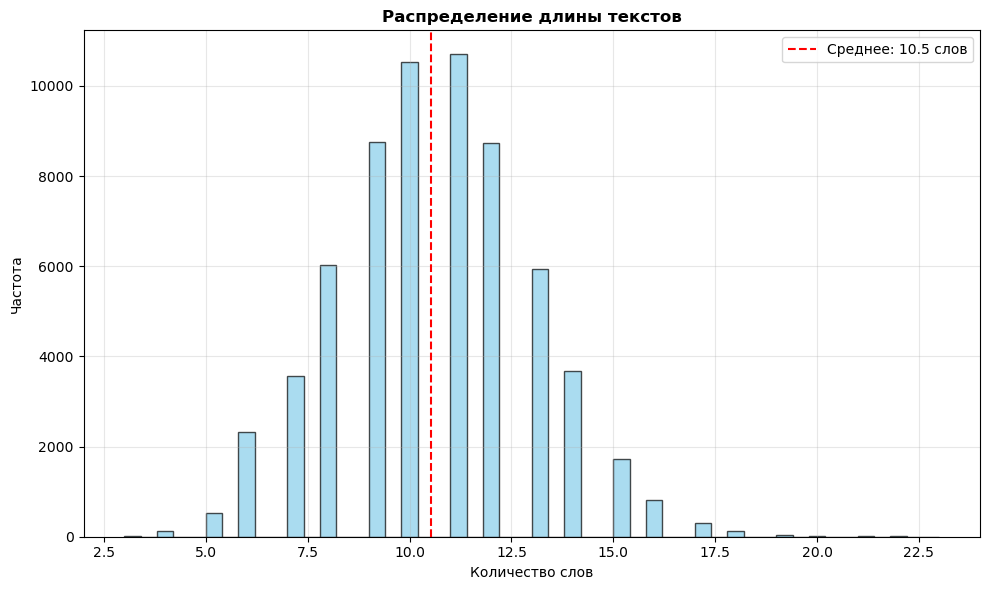

In [49]:
plot_word_count_distribution(df_interfax, 'text')

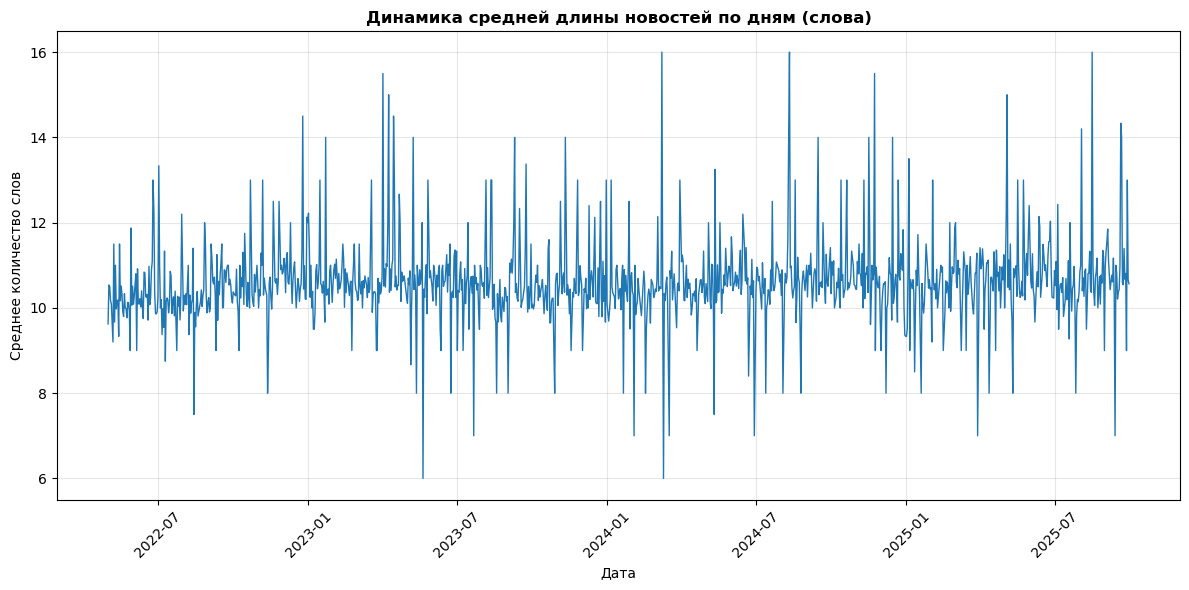

In [21]:
plot_daily_word_length_evolution(df_interfax, 'text', 'date')

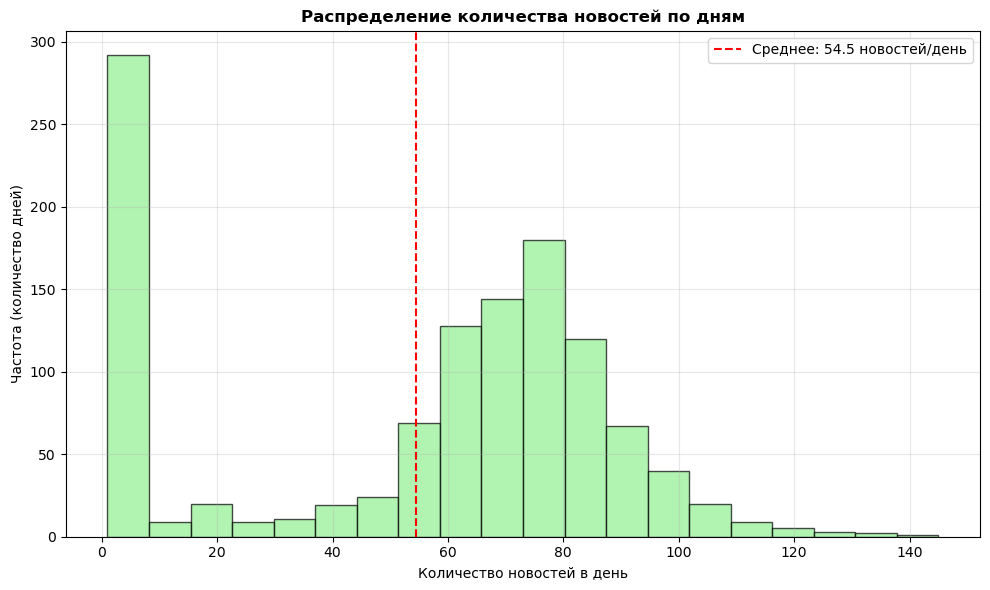

In [22]:
plot_news_count_distribution(df_interfax, 'date')

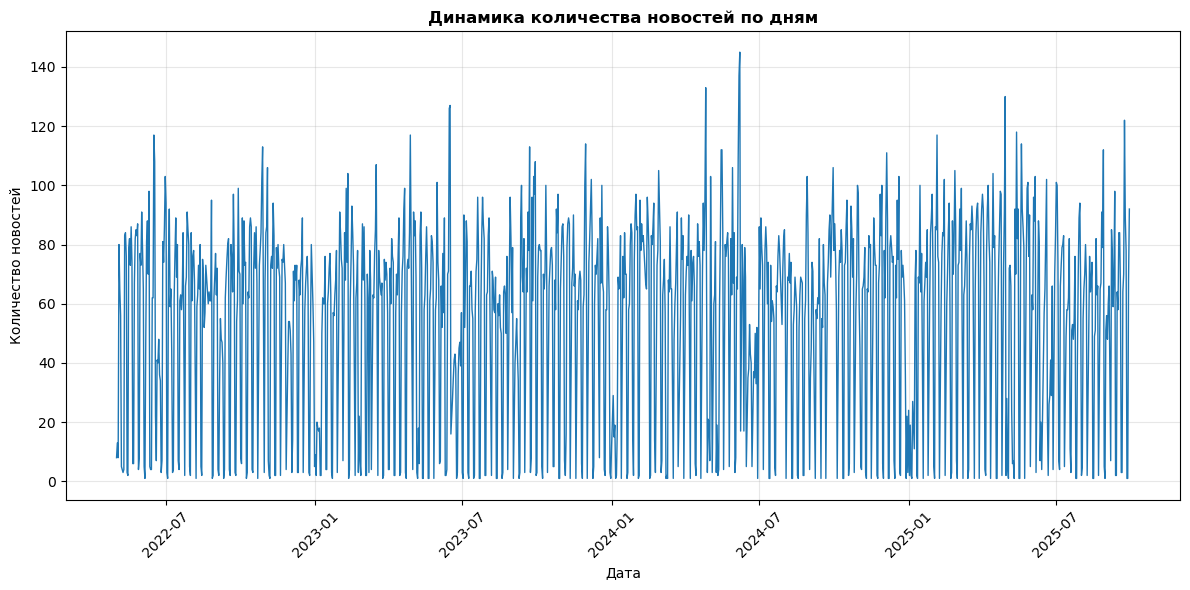

In [23]:
plot_daily_news_count_evolution(df_interfax, 'date')

**Вывод:** В данном источнике новости короткие (в среднем 10,5 слов) и их длина в целом стабильна. Имеется много дней, где количество новостей в день очень близко к 0, что, возможно, говорит о непостоянстве источника. Источник содержит только экономические новости.

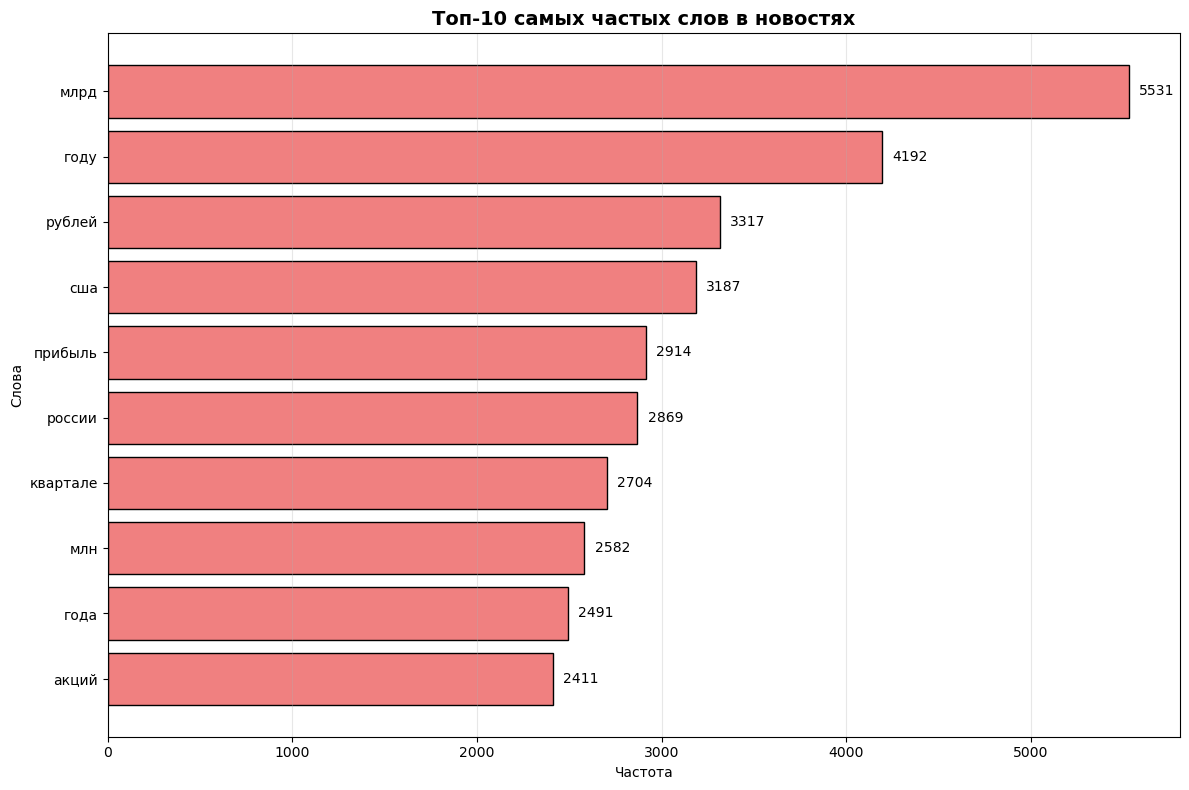

In [24]:
plot_top_words(df_interfax, 'text', top_n = 10)

## 3.2. Анализ новостей vedomosti

In [25]:
df_vedomosti.head(1)

,date,topic,text,heading
0,2022-05-01 13:27:05,economics,"За четыре месяца 2022 г. «Газпром» поставил в Китай на 60% больше газа по сравнению с аналогичным периодом прошлого года, сообщает пресс-служба российской энергетической компании. Экспорт газа в Китай по газопроводу «Сила Сибири» осуществляется в рамках двустороннего долгосрочного контракта между «Газпромом» и CNPC. «Объем поставок за первые четыре месяца 2022 г. превышает аналогичный показатель прошлого года почти на 60%», — заявили в компании в субботу. Экспорт в страны дальнего зарубежья снизился на 26,9% по сравнению с прошлым годом и составил 50,1 млрд куб. м. Поставки «Газпрома» из газотранспортной системы на внутренний рынок снизились на 3,7%, компания объясняет это теплой погодой в феврале, говорится в сообщении. По предварительным данным, в январе - апреле «Газпром», добыл 175,4 млрд куб. м газа, что на 2,5% меньше, чем в прошлом году. Компания также приводит данные Gas Infrastructure Europe, согласно которым на 29 апреля запасы газа в европейских ПХГ восполнены на 6,9 млрд куб. м. «Для выхода на уровень 90% заполненности хранилищ, продекларированный Европейским союзом как целевой, компаниям предстоит закачать еще около 56 млрд куб. м газа», — отмечает «Газпром». В конце апреля «Газпром» отчитался о рекордных прибылях за IV квартал и весь 2021 г. Компания заработала 2,09 трлн руб. чистой прибыли по МСФО против 135 млрд руб. годом ранее. Выручка монополии увеличилась на 62% и достигла 10,24 трлн руб., показатель EBITDA вырос за отчетный период в 1,5 раза до 3,69 трлн руб. Чистая выручка от продажи газа выросла на 85% до 5,7 трлн руб., а от продажи продуктов нефтегазопереработки – на 44% и составила 2,6 трлн руб.",«Газпром» заявил о наращивании поставок газа в Китай на 60%


In [26]:
df_vedomosti.duplicated().sum()

0

In [27]:
df_vedomosti.isna().sum()

date         0
topic        0
text       460
heading    460
dtype: int64

In [28]:
df_vedomosti.dropna(inplace = True)

In [29]:
df_vedomosti.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37276 entries, 0 to 37735
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     37276 non-null  datetime64[ns]
 1   topic    37276 non-null  object        
 2   text     37276 non-null  object        
 3   heading  37276 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 1.4+ MB


**Вывод:** В данных имелось немного пропусков, которые было принято решение удалить, дубликаты отстутствуют.

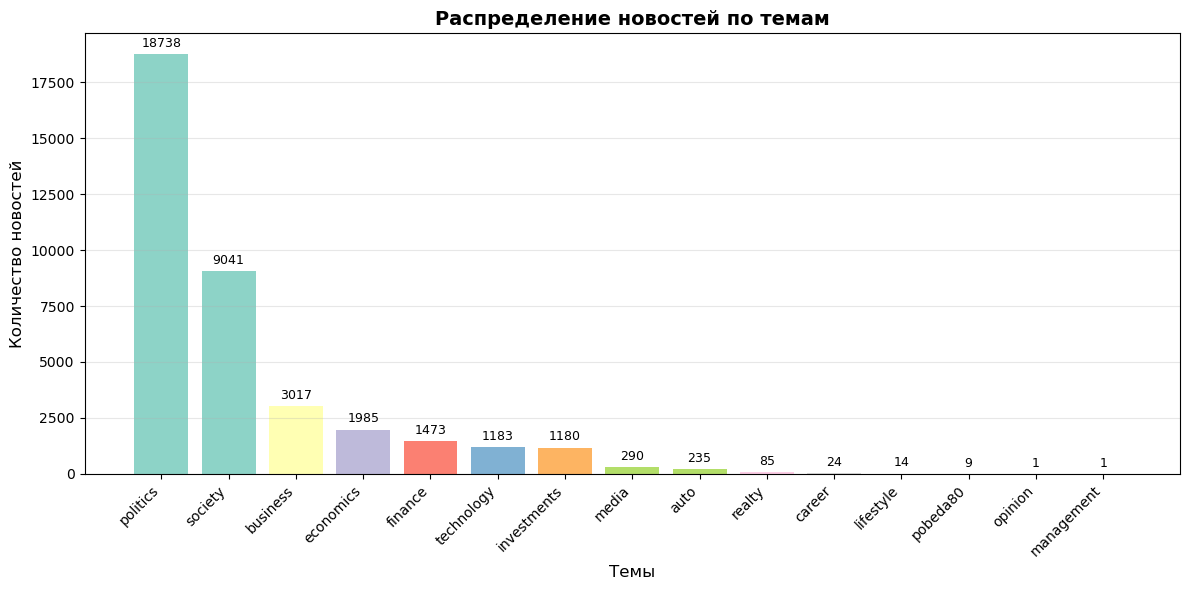

In [30]:
plot_topic_barchart(df_vedomosti, 'topic')

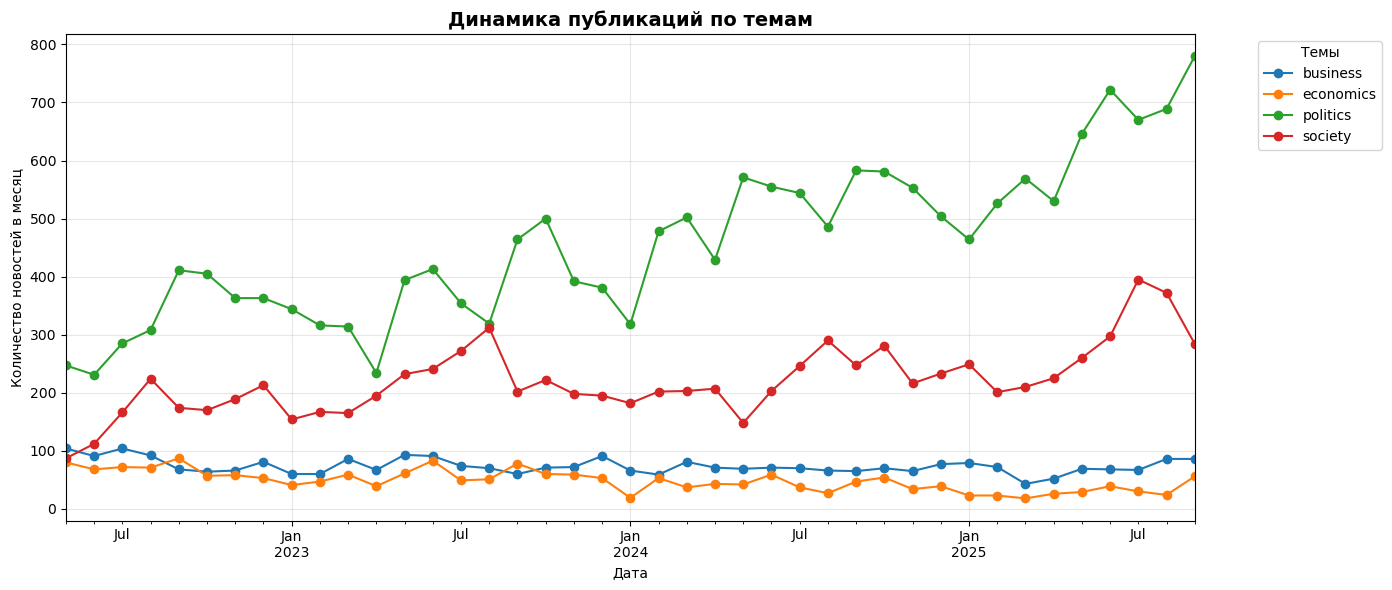

In [31]:
plot_topic_timeseries(df_vedomosti, 'topic', 'date', top_n = 4)

**Вывод:** В распределении тем сильный дисбаланс классов. Имеются темы, в которых очень мало новостей, в дальнейшем стоит рассмотреть удаление или объединение некоторых из них. Источник содержит в основном политические новости, количество публикаций которых постоянно увеличивается.

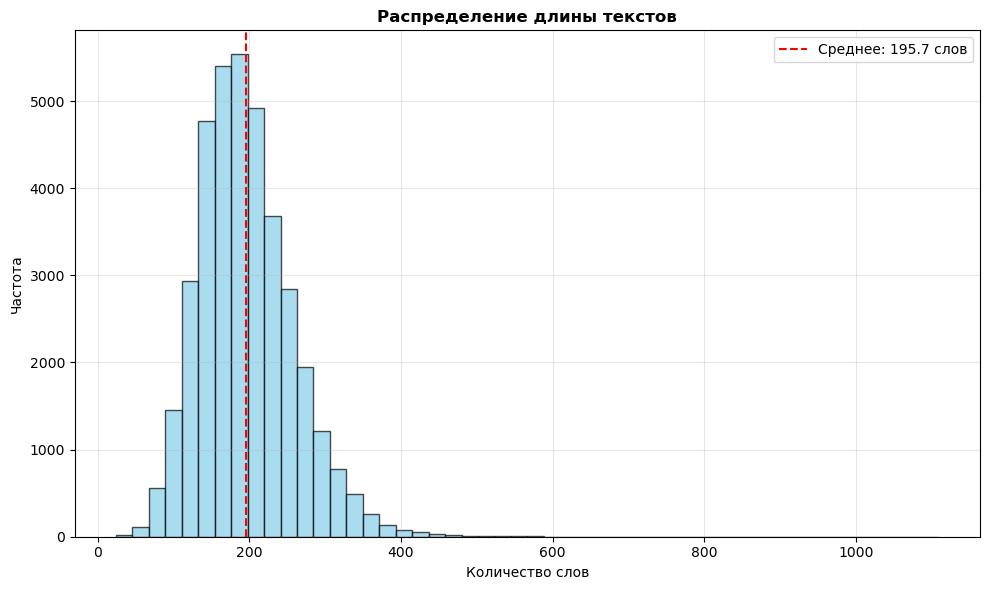

In [50]:
plot_word_count_distribution(df_vedomosti, 'text')

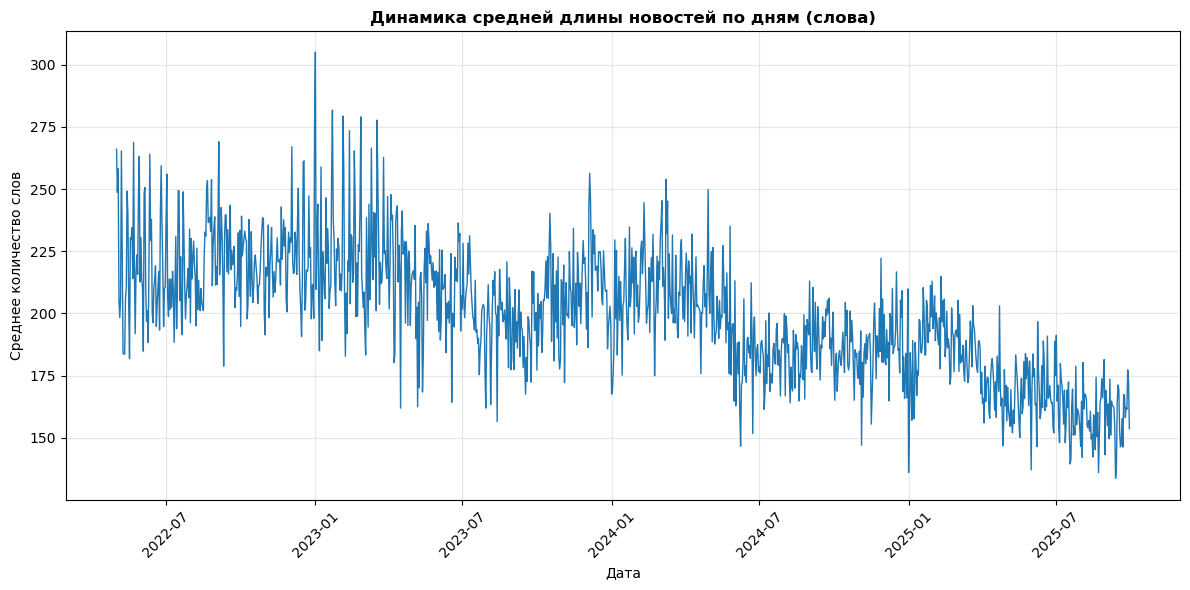

In [33]:
plot_daily_word_length_evolution(df_vedomosti, 'text', 'date')

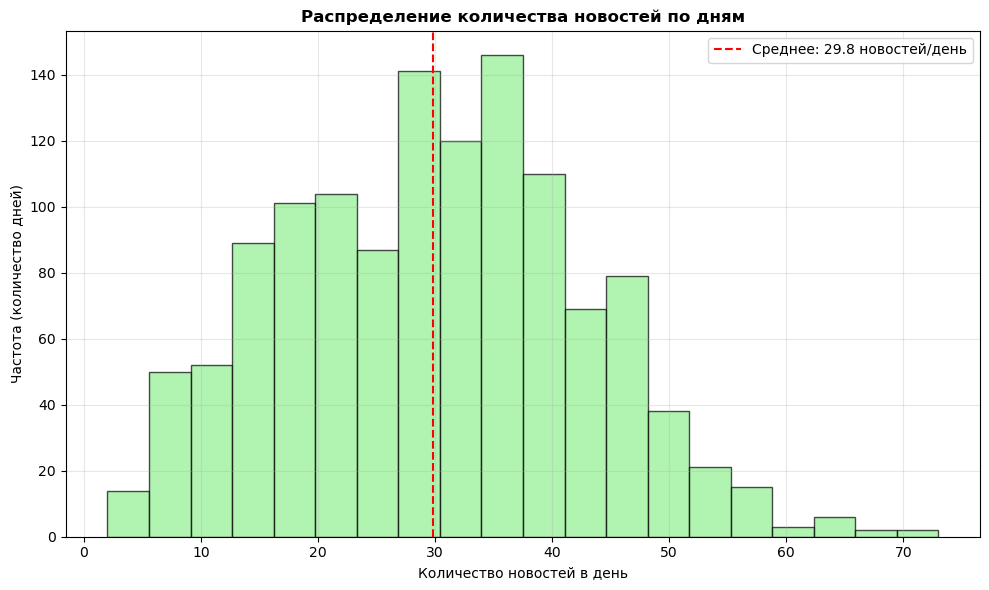

In [34]:
plot_news_count_distribution(df_vedomosti, 'date')

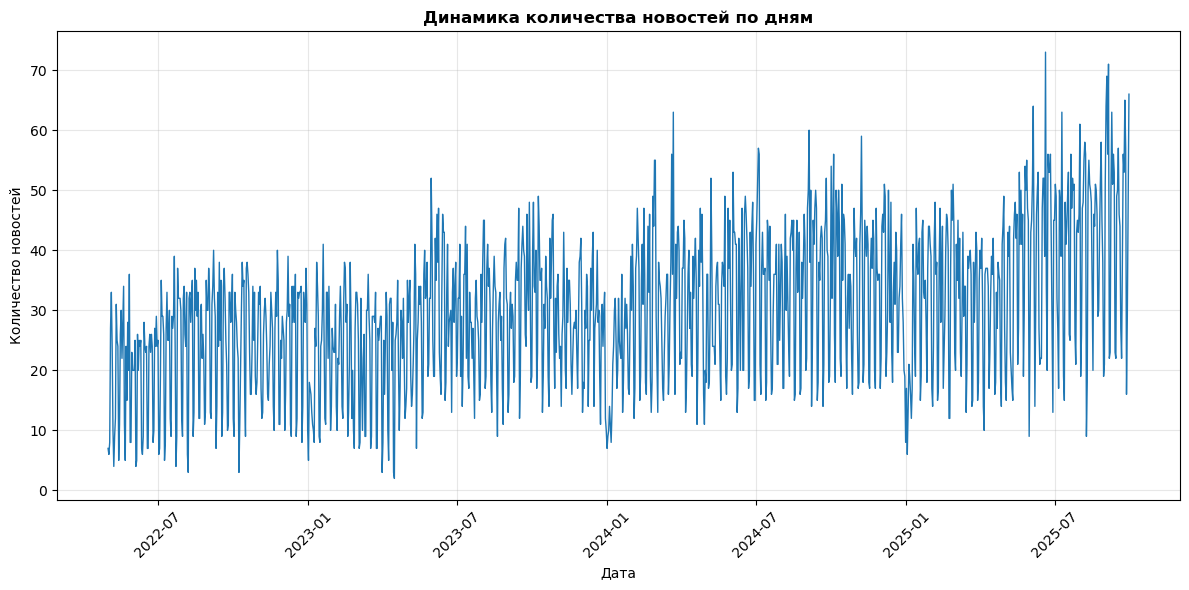

In [35]:
plot_daily_news_count_evolution(df_vedomosti, 'date')

**Вывод:** В данном источнике содержатся длинные новости (в среднем почти 200 слов), их длина со временем уменьшается, а количество - увеличивается.

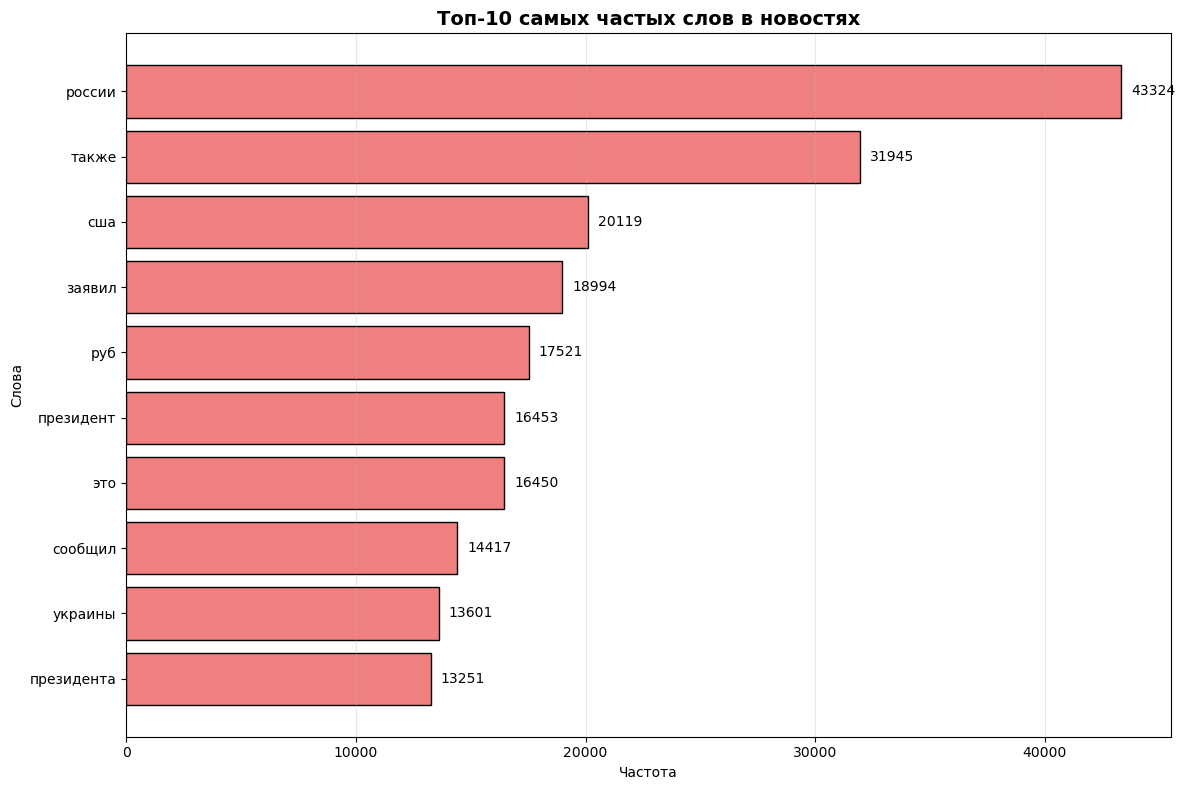

In [36]:
plot_top_words(df_vedomosti, 'text', top_n = 10)

## 3.3. Анализ новостей kommersant

In [37]:
df_kommersant.head(1)

,date,topic,text,heading
0,2022-05-01 14:55:00,economics,"Президент России Владимир Путин подписал закон, который позволит поддержать финансовую стабильность региональных и местных бюджетов в условиях санкций, в том числе путем выделения новых кредитов из федерального бюджета и реструктуризации или списания старых. Документ опубликован на официальном портале правовой информации. Согласно закону, в 2022 году из федерального бюджета российские субъекты получат кредиты в общей сумме до 390,7 млрд руб. С помощью этих средств планируется погасить долговые обязательства регионов и муниципалитетов по государственным и муниципальным ценным бумагам и коммерческим кредитам, чей срок погашения приходится на март-декабрь. Кредиты со сроком погашения до 2029 года под 0,1% годовых предоставят регионам, чей показатель уровня расчетной бюджетной обеспеченности на текущий год не превышает 1,5%. Первоначально предусматривалось, что из федерального бюджета регионам направят до 255,3 млрд руб. на погашение только долговых обязательств. Однако депутаты Госдумы во втором чтении поддержали поправку, предусматривающую использование таких кредитов и на погашение аналогичных муниципальных обязательств. В связи с этим общий объем бюджетных кредитов, предоставляемых регионам на соответствующие цели, увеличили на 134,5 млрд руб. Также документом предусмотрено предоставление в текущем году «казначейских» кредитов (на пополнение остатка средств на едином счете бюджета) для регионов в размере, не превышающем 10% утвержденных доходов их бюджетов, и с возвратом не позднее 30 декабря 2022 года. Правительство установит порядок и условия предоставления таких кредитов. Кроме прочего, регионы в текущем году освободят от исполнения обязательств по ранее реструктурированной задолженности по бюджетным кредитам. Ее погашение было решено перенести на 2029 год. В текущем году может быть реструктурирована или списана правительством задолженность по ранее не реструктурированным бюджетным кредитам на частичное покрытие дефицитов региональных бюджетов, срок погашения которых наступает в текущем году. Реструктуризация предусматривает, что задолженность по основному долгу и процентам по таким кредитам в 2022 году погашению не подлежит. С 2023 по 2024 год погасят ежегодно по 5% суммы задолженности, а с 2025 по 2029 год — ежегодно равными долями от остатка задолженности с возможностью досрочного погашения. В закон была внесена поправка, предусматривающая перенос с текущего года на 2025 год погашения задолженности по основному долгу и процентам по бюджетным кредитам для Тамбовской и Псковской областей, Республики Марий Эл и Приморского края, что позволит регионам присоединиться к реструктуризации.",Путин подписал закон о дополнительной поддержке регионов в условиях санкций


In [38]:
df_kommersant.duplicated().sum()

0

In [39]:
df_kommersant.isna().sum()

date       0
topic      0
text       0
heading    0
dtype: int64

In [40]:
df_kommersant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20971 entries, 0 to 20970
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   date     20971 non-null  object
 1   topic    20971 non-null  object
 2   text     20971 non-null  object
 3   heading  20971 non-null  object
dtypes: object(4)
memory usage: 655.5+ KB


**Вывод:** Пропуски и дубликаты в данных отстутствуют.

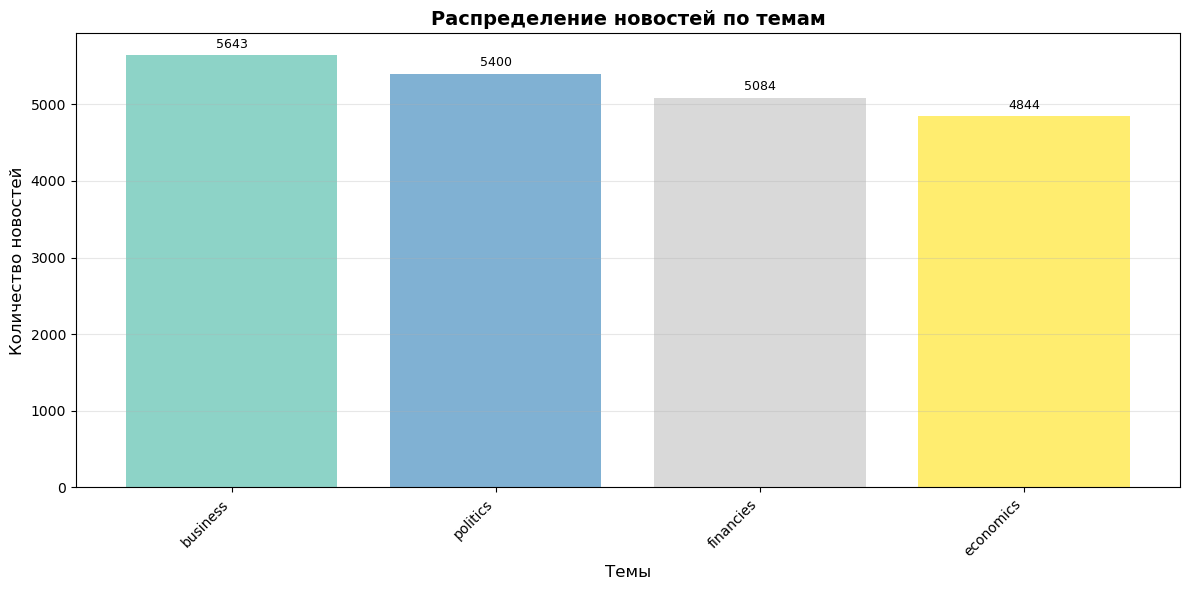

In [41]:
plot_topic_barchart(df_kommersant, 'topic')

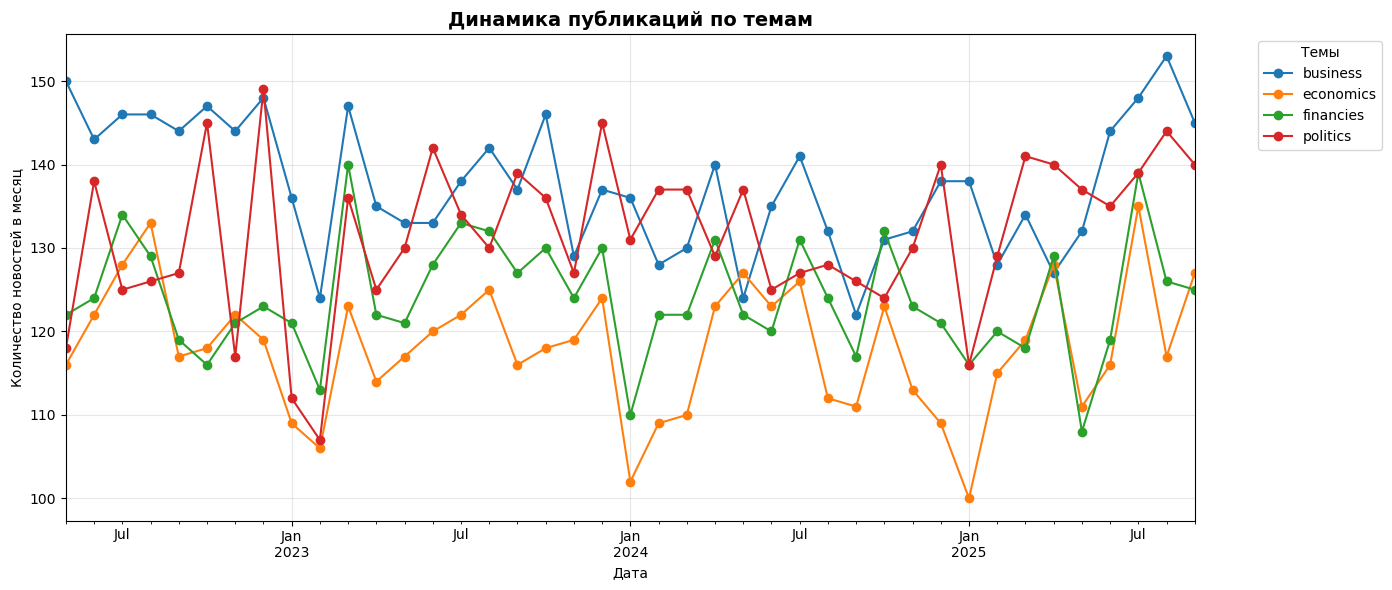

In [42]:
plot_topic_timeseries(df_kommersant, 'topic', 'date', top_n = 4)

**Вывод:** Распределение тем равномерное. Динамика публикаций стабильная, резких скачков нет.

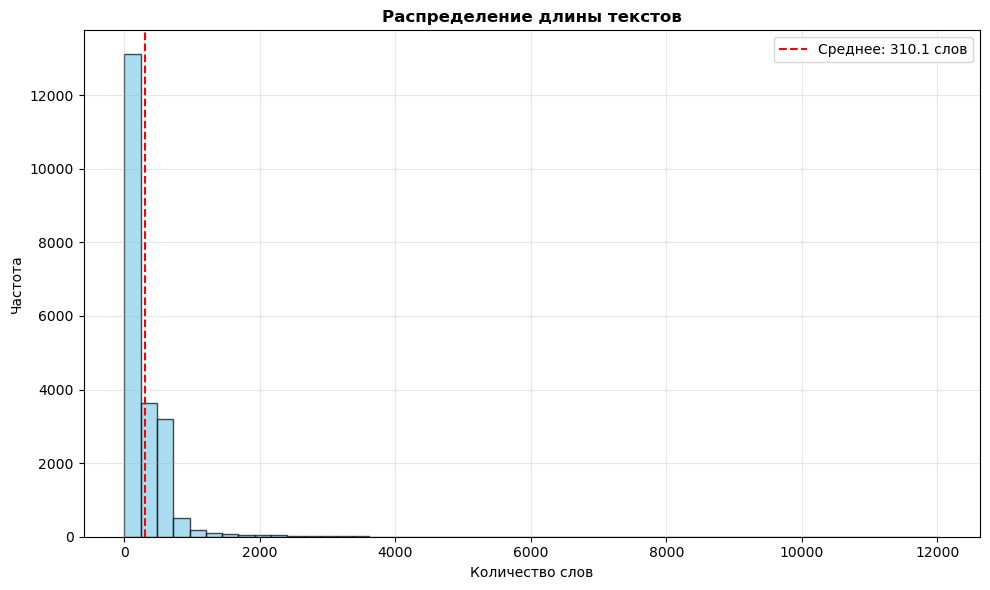

In [51]:
plot_word_count_distribution(df_kommersant, 'text')

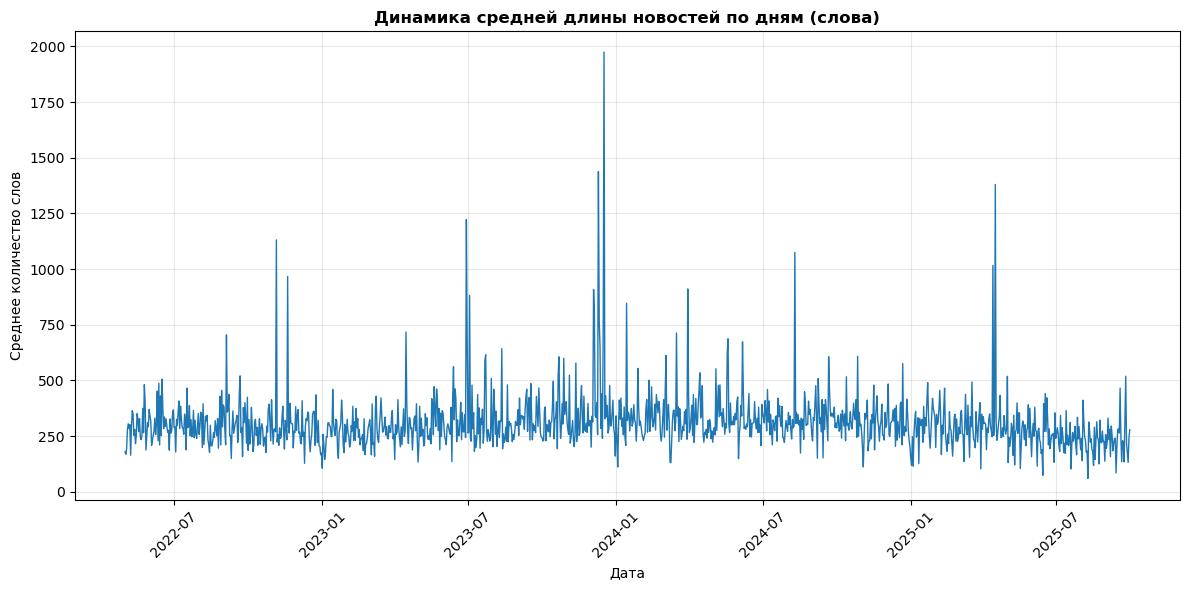

In [44]:
plot_daily_word_length_evolution(df_kommersant, 'text', 'date')

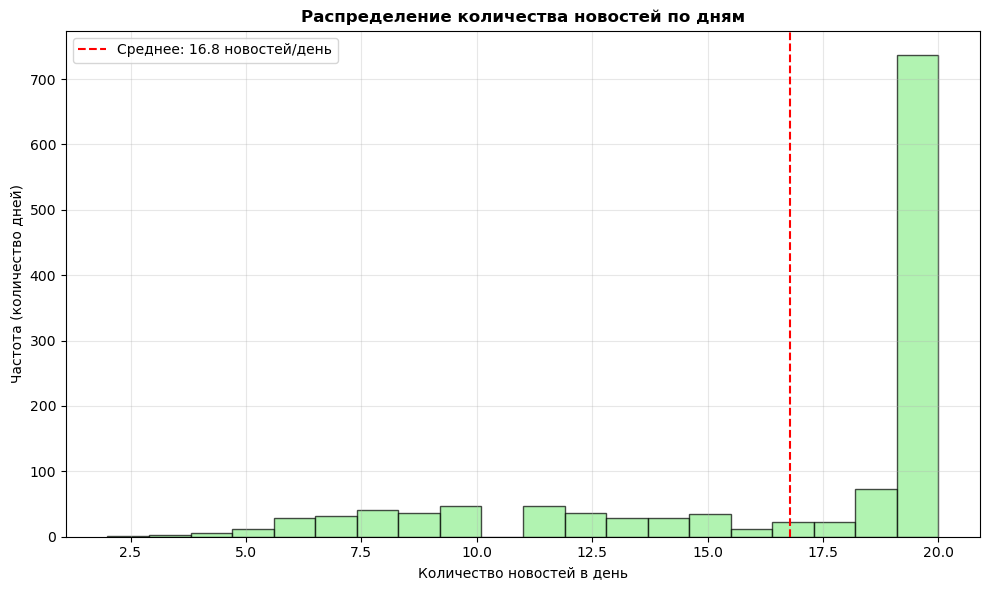

In [45]:
plot_news_count_distribution(df_kommersant, 'date')

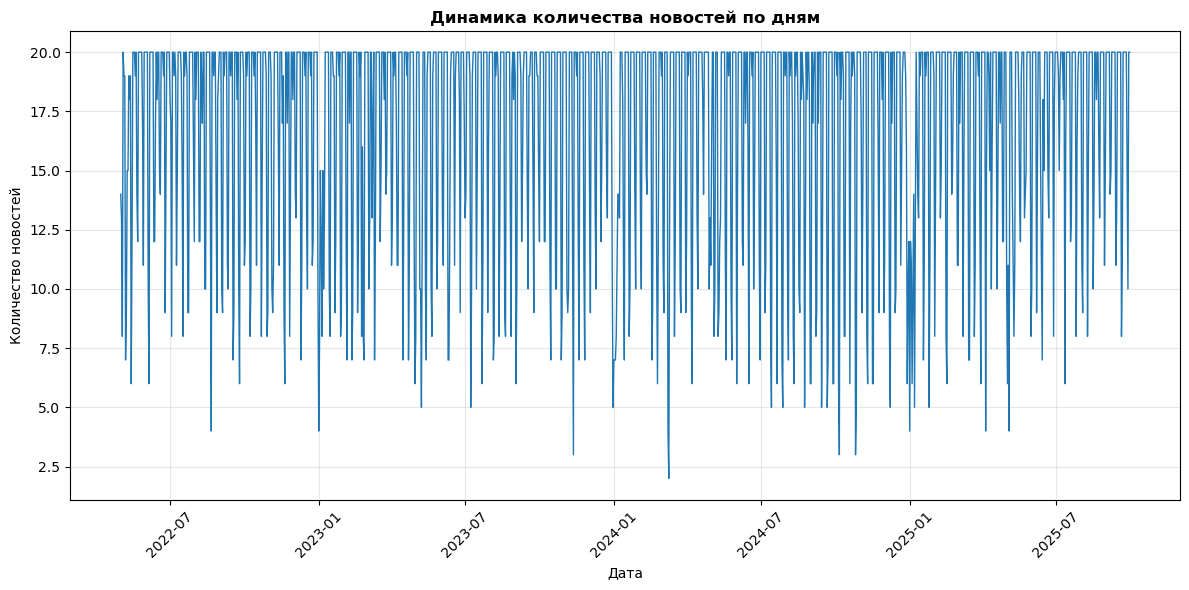

In [46]:
plot_daily_news_count_evolution(df_kommersant, 'date')

**Вывод:** В данном источнике новости длинные (В среднем более 300 слов). В длине имеется немного аномально больших значений. Кроме этого, количество новостей выпускаемых в день ограничивается строго числом 20.

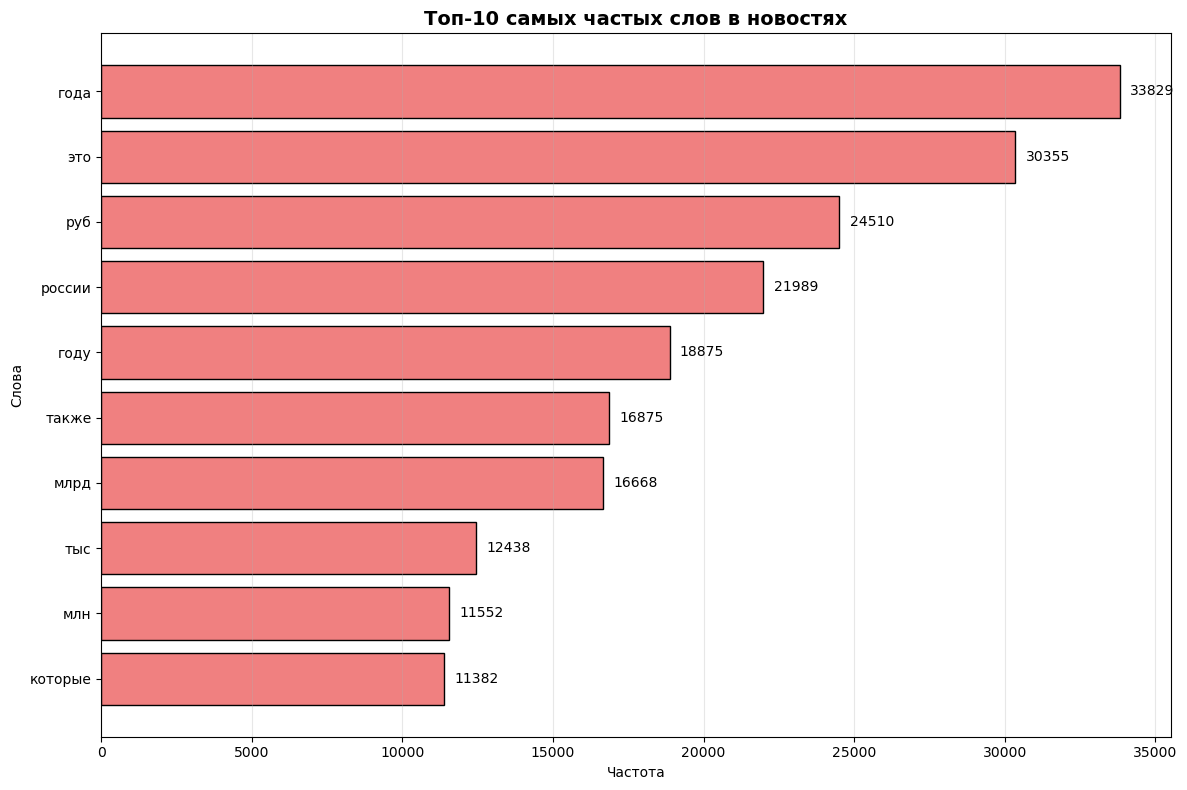

In [47]:
plot_top_words(df_kommersant, 'text', top_n = 10)